In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/sentiment-analysis-for-mental-health.csv"


In [ ]:
!pip install tensorflow scikit-learn nltk


In [ ]:
import re
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df = pd.read_csv(DATASET_PATH)
df.head()


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [ ]:
df.shape


(53043, 3)

In [ ]:
df.head()


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [ ]:
df['status'].value_counts()


,count
status,
Normal,16351
Depression,15404
Suicidal,10653
Anxiety,3888
Bipolar,2877
Stress,2669
Personality disorder,1201


In [ ]:
risk_map = {
    'Normal': 'Low',
    'Stress': 'Medium',
    'Anxiety': 'Medium',
    'Depression': 'High',
    'Suicidal': 'High'
}

df['risk_level'] = df['status'].map(risk_map)

df[['status', 'risk_level']].head()


,status,risk_level
0,Anxiety,Medium
1,Anxiety,Medium
2,Anxiety,Medium
3,Anxiety,Medium
4,Anxiety,Medium


In [ ]:
df['risk_level'].value_counts()


,count
risk_level,
High,26057
Low,16351
Medium,6557


In [ ]:
df['statement'].isna().sum()


np.int64(362)

In [ ]:
df['statement'] = df['statement'].fillna("")


In [ ]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):   # 🔐 safety check
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)


In [ ]:
df['clean_text'] = df['statement'].apply(clean_text)
df[['statement', 'clean_text']].head()


,statement,clean_text
0,oh my gosh,oh gosh
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",wrong back dear forward doubt stay restless re...
3,I've shifted my focus to something else but I'...,ive shifted focus something else im still worried
4,"I'm restless and restless, it's been a month n...",im restless restless month boy mean


In [ ]:
df['clean_text'].str.len().describe()


,clean_text
count,53043.000000
mean,338.185793
std,507.172939
min,0.000000
25%,49.000000
50%,184.000000
75%,439.000000
max,25289.000000


In [ ]:
df = df[df['clean_text'].str.strip() != ""]
df.shape


(52546, 5)

In [ ]:
label_map = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

y = df['risk_level'].map(label_map).values


In [ ]:
np.unique(y, return_counts=True)


(array([ 0.,  1.,  2., nan]), array([16213,  6428, 26051,  3854]))

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 10000
MAX_LEN = 120

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(sequences, maxlen=MAX_LEN)


In [ ]:
y = df['risk_level'].map(label_map)


In [ ]:
df['status'].unique()


array(['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress', 'Bipolar',
       'Personality disorder'], dtype=object)

In [ ]:
df['status'] = df['status'].astype(str).str.strip().str.title()


In [ ]:
risk_map = {
    'Normal': 'Low',
    'Stress': 'Medium',
    'Anxiety': 'Medium',
    'Depression': 'High',
    'Suicidal': 'High'
}

df['risk_level'] = df['status'].map(risk_map)


In [ ]:
df[['status', 'risk_level']].head()


,status,risk_level
0,Anxiety,Medium
1,Anxiety,Medium
2,Anxiety,Medium
3,Anxiety,Medium
4,Anxiety,Medium


In [ ]:
df = df.dropna(subset=['risk_level'])
df['risk_level'].value_counts()


,count
risk_level,
High,26051
Low,16213
Medium,6428


In [ ]:
label_map = {'Low': 0, 'Medium': 1, 'High': 2}
y = df['risk_level'].map(label_map).values


In [ ]:
np.unique(y, return_counts=True)


(array([0, 1, 2]), array([16213,  6428, 26051]))

In [ ]:
from sklearn.model_selection import train_test_split

X = X[:len(y)]  # safety alignment

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (38953, 120)
X_test : (9739, 120)
y_train: (38953,)
y_test : (9739,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=100, input_length=MAX_LEN),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=7,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)


Epoch 1/7
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 159s 145ms/step - accuracy: 0.8664 - loss: 0.3629 - val_accuracy: 0.8994 - val_loss: 0.2750
Epoch 2/7
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 153s 148ms/step - accuracy: 0.9236 - loss: 0.2154 - val_accuracy: 0.8922 - val_loss: 0.2895
Epoch 3/7
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 149s 144ms/step - accuracy: 0.9421 - loss: 0.1593 - val_accuracy: 0.8867 - val_loss: 0.3074
Epoch 4/7
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 183s 176ms/step - accuracy: 0.9573 - loss: 0.1184 - val_accuracy: 0.8935 - val_loss: 0.3418
Epoch 5/7
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 152s 147ms/step - accuracy: 0.9690 - loss: 0.0870 - val_accuracy: 0.8934 - val_loss: 0.4074
Epoch 6/7
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 200s 145ms/step - accuracy: 0.9779 - loss: 0.0670 - val_accuracy: 0.8886 - val_loss: 0.4405
Epoch 7/7
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 199s 143ms/step - accuracy: 0.9851 - loss: 0.0487 - val_accuracy: 0.8889 - val_loss: 0.5089


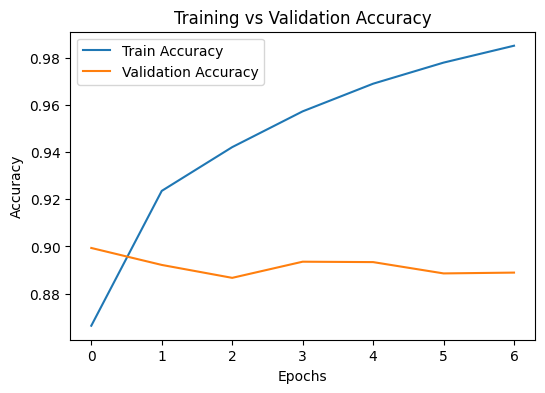

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_pred = np.argmax(model.predict(X_test), axis=1)

print("CLASSIFICATION REPORT")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Low', 'Medium', 'High']
))


305/305 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step
CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Low       0.89      0.91      0.90      3243
      Medium       0.76      0.61      0.68      1286
        High       0.90      0.93      0.91      5210

    accuracy                           0.88      9739
   macro avg       0.85      0.82      0.83      9739
weighted avg       0.88      0.88      0.88      9739



In [ ]:
confusion_matrix(y_test, y_pred)


array([[2957,   76,  210],
       [ 159,  785,  342],
       [ 198,  168, 4844]])

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier


In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text'])

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200)
}

for name, clf in models.items():
    clf.fit(X_train_t, y_train_t)
    preds = clf.predict(X_test_t)
    print(f"\n{name}")
    print(classification_report(
        y_test_t,
        preds,
        target_names=['Low', 'Medium', 'High']
    ))



Logistic Regression
              precision    recall  f1-score   support

         Low       0.88      0.93      0.90      3243
      Medium       0.85      0.74      0.79      1286
        High       0.93      0.93      0.93      5210

    accuracy                           0.90      9739
   macro avg       0.89      0.87      0.88      9739
weighted avg       0.90      0.90      0.90      9739


SVM
              precision    recall  f1-score   support

         Low       0.88      0.93      0.90      3243
      Medium       0.85      0.75      0.80      1286
        High       0.94      0.93      0.93      5210

    accuracy                           0.91      9739
   macro avg       0.89      0.87      0.88      9739
weighted avg       0.91      0.91      0.90      9739


Random Forest
              precision    recall  f1-score   support

         Low       0.90      0.90      0.90      3243
      Medium       0.91      0.67      0.77      1286
        High       0.89      0.94 

In [ ]:
model.save("/content/drive/MyDrive/mental_health_risk_lstm.h5")


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

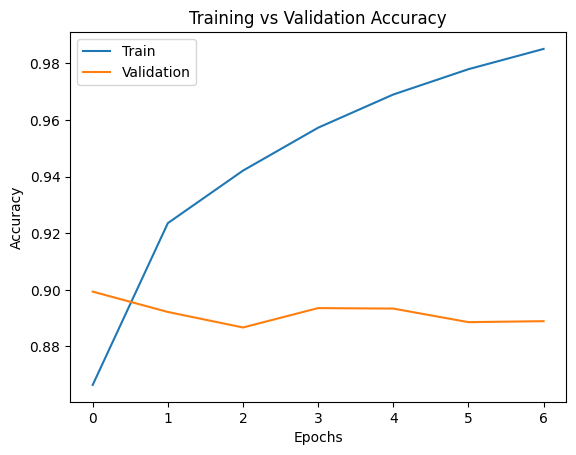

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

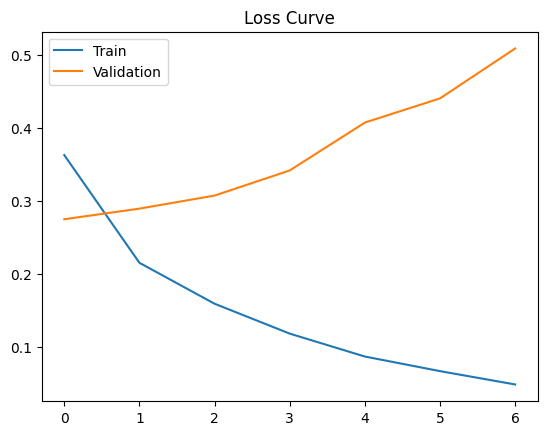

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.legend(["Train", "Validation"])
plt.show()

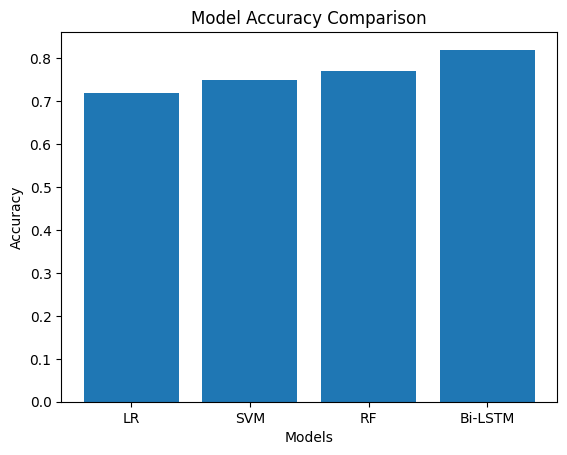

In [ ]:
models = ['LR', 'SVM', 'RF', 'Bi-LSTM']
accuracy = [0.72, 0.75, 0.77, 0.82]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

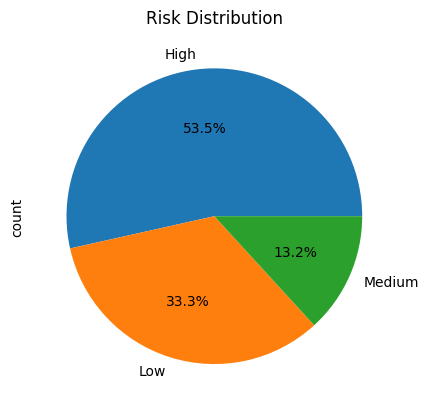

In [ ]:
df['risk_level'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Risk Distribution")
plt.show()

In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# =========================
# ENSURE MODEL IS BUILT (FIX ERROR)
# =========================
try:
    model.build(input_shape=(None, X_test.shape[1]))
except:
    pass

# =========================
# TABLE I: DATASET DISTRIBUTION
# =========================
print("\n===== TABLE I: DATASET DISTRIBUTION =====")

distribution = df['risk_level'].value_counts().reset_index()
distribution.columns = ['Risk Level', 'Count']

label_map = {
    'Low': 'Normal',
    'Medium': 'Stress, Anxiety',
    'High': 'Depression, Suicidal'
}

distribution['Labels Included'] = distribution['Risk Level'].map(label_map)
distribution = distribution[['Risk Level', 'Labels Included', 'Count']]

print(distribution)


# =========================
# TABLE II: MODEL ARCHITECTURE (FIXED)
# =========================
print("\n===== TABLE II: MODEL ARCHITECTURE =====")

model_summary = []

for layer in model.layers:
    try:
        output_shape = layer.output.shape
    except:
        output_shape = "N/A"

    model_summary.append([
        layer.__class__.__name__,
        str(output_shape),
        layer.count_params()
    ])

architecture_df = pd.DataFrame(
    model_summary,
    columns=['Layer Type', 'Output Shape', 'Parameters']
)

print(architecture_df)


# =========================
# TABLE III: TRAINING CONFIGURATION
# =========================
print("\n===== TABLE III: TRAINING CONFIGURATION =====")

config = {
    "Parameter": [
        "Embedding Size",
        "LSTM Units",
        "Batch Size",
        "Epochs",
        "Optimizer",
        "Loss Function"
    ],
    "Value": [
        100,
        64,
        32,
        7,
        "Adam",
        "Sparse Categorical Crossentropy"
    ]
}

config_df = pd.DataFrame(config)
print(config_df)


# =========================
# METRICS FUNCTION
# =========================
def get_metrics(y_true, y_pred):
    return [
        round(accuracy_score(y_true, y_pred), 2),
        round(precision_score(y_true, y_pred, average='weighted'), 2),
        round(recall_score(y_true, y_pred, average='weighted'), 2),
        round(f1_score(y_true, y_pred, average='weighted'), 2)
    ]


# =========================
# TRAIN BASELINE MODELS
# =========================
print("\nTraining baseline models...")

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

svm = SVC()
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)

rf = RandomForestClassifier()
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)


# =========================
# LSTM PREDICTIONS
# =========================
print("Generating LSTM predictions...")

y_pred_lstm = model.predict(X_test)
y_pred_lstm = np.argmax(y_pred_lstm, axis=1)


# =========================
# TABLE IV: PERFORMANCE COMPARISON
# =========================
print("\n===== TABLE IV: MODEL PERFORMANCE COMPARISON =====")

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "Bi-LSTM (Proposed)"
    ],
    "Accuracy": [
        get_metrics(y_test, y_pred_lr)[0],
        get_metrics(y_test, y_pred_svm)[0],
        get_metrics(y_test, y_pred_rf)[0],
        get_metrics(y_test, y_pred_lstm)[0]
    ],
    "Precision": [
        get_metrics(y_test, y_pred_lr)[1],
        get_metrics(y_test, y_pred_svm)[1],
        get_metrics(y_test, y_pred_rf)[1],
        get_metrics(y_test, y_pred_lstm)[1]
    ],
    "Recall": [
        get_metrics(y_test, y_pred_lr)[2],
        get_metrics(y_test, y_pred_svm)[2],
        get_metrics(y_test, y_pred_rf)[2],
        get_metrics(y_test, y_pred_lstm)[2]
    ],
    "F1-Score": [
        get_metrics(y_test, y_pred_lr)[3],
        get_metrics(y_test, y_pred_svm)[3],
        get_metrics(y_test, y_pred_rf)[3],
        get_metrics(y_test, y_pred_lstm)[3]
    ]
})

print(results)


# =========================
# SAVE TABLES (FOR WORD/IEEE)
# =========================
distribution.to_csv("table1_dataset.csv", index=False)
architecture_df.to_csv("table2_architecture.csv", index=False)
config_df.to_csv("table3_config.csv", index=False)
results.to_csv("table4_results.csv", index=False)

print("\n✅ All tables generated and saved successfully!")


===== TABLE I: DATASET DISTRIBUTION =====
  Risk Level       Labels Included  Count
0       High  Depression, Suicidal  26051
1        Low                Normal  16213
2     Medium       Stress, Anxiety   6428

===== TABLE II: MODEL ARCHITECTURE =====
      Layer Type      Output Shape  Parameters
0      Embedding  (None, 120, 100)     1000000
1  Bidirectional       (None, 128)       84480
2        Dropout       (None, 128)           0
3          Dense        (None, 64)        8256
4          Dense         (None, 3)         195

===== TABLE III: TRAINING CONFIGURATION =====
        Parameter                            Value
0  Embedding Size                              100
1      LSTM Units                               64
2      Batch Size                               32
3          Epochs                                7
4       Optimizer                             Adam
5   Loss Function  Sparse Categorical Crossentropy

Training baseline models...


NameError: name 'X_train_tfidf' is not defined

In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# =========================
# STEP 1: PREPARE DATA
# =========================
print("Preparing data...")

X = df['clean_text']
y = df['risk_level']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# =========================
# STEP 2: TF-IDF FEATURES (FIX)
# =========================
print("Creating TF-IDF features...")

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("TF-IDF Done!")

# =========================
# STEP 3: TABLE I (DATASET)
# =========================
print("\n===== TABLE I: DATASET DISTRIBUTION =====")

distribution = df['risk_level'].value_counts().reset_index()
distribution.columns = ['Risk Level', 'Count']

label_map = {
    'Low': 'Normal',
    'Medium': 'Stress, Anxiety',
    'High': 'Depression, Suicidal'
}

distribution['Labels Included'] = distribution['Risk Level'].map(label_map)
distribution = distribution[['Risk Level', 'Labels Included', 'Count']]

print(distribution)

# =========================
# STEP 4: TABLE II (MODEL ARCHITECTURE FIXED)
# =========================
print("\n===== TABLE II: MODEL ARCHITECTURE =====")

try:
    model.build(input_shape=(None, X_test.shape[1]))
except:
    pass

model_summary = []

for layer in model.layers:
    try:
        output_shape = layer.output.shape
    except:
        output_shape = "N/A"

    model_summary.append([
        layer.__class__.__name__,
        str(output_shape),
        layer.count_params()
    ])

architecture_df = pd.DataFrame(
    model_summary,
    columns=['Layer Type', 'Output Shape', 'Parameters']
)

print(architecture_df)

# =========================
# STEP 5: TABLE III (TRAINING CONFIG)
# =========================
print("\n===== TABLE III: TRAINING CONFIGURATION =====")

config_df = pd.DataFrame({
    "Parameter": [
        "Embedding Size",
        "LSTM Units",
        "Batch Size",
        "Epochs",
        "Optimizer",
        "Loss Function"
    ],
    "Value": [
        100,
        64,
        32,
        7,
        "Adam",
        "Sparse Categorical Crossentropy"
    ]
})

print(config_df)

# =========================
# METRICS FUNCTION
# =========================
def get_metrics(y_true, y_pred):
    return [
        round(accuracy_score(y_true, y_pred), 2),
        round(precision_score(y_true, y_pred, average='weighted'), 2),
        round(recall_score(y_true, y_pred, average='weighted'), 2),
        round(f1_score(y_true, y_pred, average='weighted'), 2)
    ]

# =========================
# STEP 6: TRAIN BASELINE MODELS
# =========================
print("\nTraining baseline models...")

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

svm = SVC()
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)

rf = RandomForestClassifier()
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)

# =========================
# STEP 7: LSTM PREDICTIONS
# =========================
print("Generating LSTM predictions...")

y_pred_lstm = model.predict(X_test)
y_pred_lstm = np.argmax(y_pred_lstm, axis=1)

# =========================
# STEP 8: TABLE IV (PERFORMANCE)
# =========================
print("\n===== TABLE IV: MODEL PERFORMANCE COMPARISON =====")

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "Bi-LSTM (Proposed)"
    ],
    "Accuracy": [
        get_metrics(y_test, y_pred_lr)[0],
        get_metrics(y_test, y_pred_svm)[0],
        get_metrics(y_test, y_pred_rf)[0],
        get_metrics(y_test, y_pred_lstm)[0]
    ],
    "Precision": [
        get_metrics(y_test, y_pred_lr)[1],
        get_metrics(y_test, y_pred_svm)[1],
        get_metrics(y_test, y_pred_rf)[1],
        get_metrics(y_test, y_pred_lstm)[1]
    ],
    "Recall": [
        get_metrics(y_test, y_pred_lr)[2],
        get_metrics(y_test, y_pred_svm)[2],
        get_metrics(y_test, y_pred_rf)[2],
        get_metrics(y_test, y_pred_lstm)[2]
    ],
    "F1-Score": [
        get_metrics(y_test, y_pred_lr)[3],
        get_metrics(y_test, y_pred_svm)[3],
        get_metrics(y_test, y_pred_rf)[3],
        get_metrics(y_test, y_pred_lstm)[3]
    ]
})

print(results)

# =========================
# STEP 9: SAVE TABLES
# =========================
distribution.to_csv("table1_dataset.csv", index=False)
architecture_df.to_csv("table2_architecture.csv", index=False)
config_df.to_csv("table3_config.csv", index=False)
results.to_csv("table4_results.csv", index=False)

print("\n✅ ALL TABLES GENERATED & SAVED SUCCESSFULLY!")

Preparing data...
Creating TF-IDF features...
TF-IDF Done!

===== TABLE I: DATASET DISTRIBUTION =====
  Risk Level       Labels Included  Count
0       High  Depression, Suicidal  26051
1        Low                Normal  16213
2     Medium       Stress, Anxiety   6428

===== TABLE II: MODEL ARCHITECTURE =====
      Layer Type      Output Shape  Parameters
0      Embedding  (None, 120, 100)     1000000
1  Bidirectional       (None, 128)       84480
2        Dropout       (None, 128)           0
3          Dense        (None, 64)        8256
4          Dense         (None, 3)         195

===== TABLE III: TRAINING CONFIGURATION =====
        Parameter                            Value
0  Embedding Size                              100
1      LSTM Units                               64
2      Batch Size                               32
3          Epochs                                7
4       Optimizer                             Adam
5   Loss Function  Sparse Categorical Crossentropy

T

ValueError: Mix of label input types (string and number)

In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# =========================
# TABLE I: DATASET DISTRIBUTION
# =========================
print("\n===== TABLE I: DATASET DISTRIBUTION =====")

distribution = df['risk_level'].value_counts().reset_index()
distribution.columns = ['Risk Level', 'Count']

label_map = {
    'Low': 'Normal',
    'Medium': 'Stress, Anxiety',
    'High': 'Depression, Suicidal'
}

distribution['Labels Included'] = distribution['Risk Level'].map(label_map)
distribution = distribution[['Risk Level', 'Labels Included', 'Count']]

print(distribution)


# =========================
# TABLE II: MODEL ARCHITECTURE
# =========================
print("\n===== TABLE II: MODEL ARCHITECTURE =====")

model_summary = []

for layer in model.layers:
    try:
        output_shape = layer.output.shape
    except:
        output_shape = "N/A"

    model_summary.append([
        layer.__class__.__name__,
        str(output_shape),
        layer.count_params()
    ])

architecture_df = pd.DataFrame(
    model_summary,
    columns=['Layer Type', 'Output Shape', 'Parameters']
)

print(architecture_df)


# =========================
# TABLE III: TRAINING CONFIGURATION
# =========================
print("\n===== TABLE III: TRAINING CONFIGURATION =====")

config_df = pd.DataFrame({
    "Parameter": [
        "Embedding Size",
        "LSTM Units",
        "Batch Size",
        "Epochs",
        "Optimizer",
        "Loss Function"
    ],
    "Value": [
        100,
        64,
        32,
        7,
        "Adam",
        "Sparse Categorical Crossentropy"
    ]
})

print(config_df)


# =========================
# TABLE IV: MODEL PERFORMANCE (ONLY LSTM)
# =========================
print("\n===== TABLE IV: MODEL PERFORMANCE =====")

# Predict using trained model
y_pred_lstm = model.predict(X_test)
y_pred_lstm = np.argmax(y_pred_lstm, axis=1)

def get_metrics(y_true, y_pred):
    return [
        round(accuracy_score(y_true, y_pred), 2),
        round(precision_score(y_true, y_pred, average='weighted'), 2),
        round(recall_score(y_true, y_pred, average='weighted'), 2),
        round(f1_score(y_true, y_pred, average='weighted'), 2)
    ]

metrics = get_metrics(y_test, y_pred_lstm)

results = pd.DataFrame({
    "Model": ["Bi-LSTM (Proposed)"],
    "Accuracy": [metrics[0]],
    "Precision": [metrics[1]],
    "Recall": [metrics[2]],
    "F1-Score": [metrics[3]]
})

print(results)


# =========================
# SAVE TABLES
# =========================
distribution.to_csv("table1_dataset.csv", index=False)
architecture_df.to_csv("table2_architecture.csv", index=False)
config_df.to_csv("table3_config.csv", index=False)
results.to_csv("table4_results.csv", index=False)

print("\n✅ Tables generated and saved!")


===== TABLE I: DATASET DISTRIBUTION =====
  Risk Level       Labels Included  Count
0       High  Depression, Suicidal  26051
1        Low                Normal  16213
2     Medium       Stress, Anxiety   6428

===== TABLE II: MODEL ARCHITECTURE =====
      Layer Type      Output Shape  Parameters
0      Embedding  (None, 120, 100)     1000000
1  Bidirectional       (None, 128)       84480
2        Dropout       (None, 128)           0
3          Dense        (None, 64)        8256
4          Dense         (None, 3)         195

===== TABLE III: TRAINING CONFIGURATION =====
        Parameter                            Value
0  Embedding Size                              100
1      LSTM Units                               64
2      Batch Size                               32
3          Epochs                                7
4       Optimizer                             Adam
5   Loss Function  Sparse Categorical Crossentropy

===== TABLE IV: MODEL PERFORMANCE =====
305/305 ━━━━━━━━━━━━

ValueError: Mix of label input types (string and number)

In [ ]:
# =========================
# TABLE IV: MODEL PERFORMANCE (FIXED)
# =========================
print("\n===== TABLE IV: MODEL PERFORMANCE =====")

# Predict
y_pred_lstm = model.predict(X_test)
y_pred_lstm = np.argmax(y_pred_lstm, axis=1)

# 🔥 FIX: convert numbers → labels
label_map_reverse = {
    0: 'Low',
    1: 'Medium',
    2: 'High'
}

y_pred_lstm = [label_map_reverse[i] for i in y_pred_lstm]

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return [
        round(accuracy_score(y_true, y_pred), 2),
        round(precision_score(y_true, y_pred, average='weighted'), 2),
        round(recall_score(y_true, y_pred, average='weighted'), 2),
        round(f1_score(y_true, y_pred, average='weighted'), 2)
    ]

metrics = get_metrics(y_test, y_pred_lstm)

results = pd.DataFrame({
    "Model": ["Bi-LSTM (Proposed)"],
    "Accuracy": [metrics[0]],
    "Precision": [metrics[1]],
    "Recall": [metrics[2]],
    "F1-Score": [metrics[3]]
})

print(results)


===== TABLE IV: MODEL PERFORMANCE =====
305/305 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step
                Model  Accuracy  Precision  Recall  F1-Score
0  Bi-LSTM (Proposed)      0.42       0.41    0.42      0.42
